In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

In [2]:
df = pd.read_csv(
    filepath_or_buffer="../../datasets/auto-mpg.data",
    sep=r"\s+",
    names=["mpg","cylinders","displacement","horsepower","weight","acceleration","model year","origin","car name"]
)
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.00,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.00,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.00,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.00,2625.0,18.6,82,1,ford ranger


In [3]:
df.replace("?", np.nan, inplace=True)
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [4]:
df = df.dropna()
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.00,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.00,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.00,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.00,2625.0,18.6,82,1,ford ranger


In [5]:
X = df.drop_duplicates().drop(columns=["car name", "mpg"])
Y = df["mpg"]

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [7]:
comp = {
    "Degree": [],
    "RMSE": [],
}
for i in range(1,6):
    comp["Degree"].append(i)
    poly = PolynomialFeatures(degree=i)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    model = LinearRegression()
    model.fit(X_train_poly, Y_train)
    Y_pred = model.predict(X_test_poly)
    comp["RMSE"].append(
        root_mean_squared_error(
            Y_test,
            Y_pred
        )
    )    
comp = pd.DataFrame(comp)
comp

,Degree,RMSE
0,1,3.272746
1,2,2.791675
2,3,3.010644
3,4,3.614695
4,5,4.324414


In [8]:
best_degree = comp.loc[
    comp["RMSE"].idxmin(),
    "Degree"
]
best_degree

np.int64(2)

In [9]:
poly = PolynomialFeatures(degree=best_degree)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, Y_train)

y_pred = model.predict(X_test_poly)

residuals = Y_test - y_pred

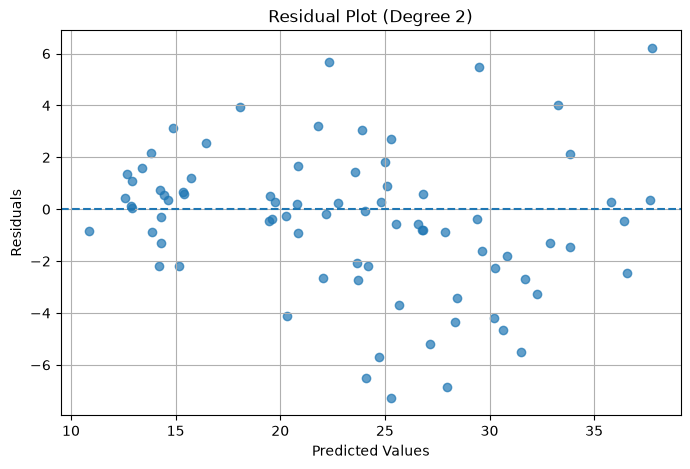

In [10]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title(f"Residual Plot (Degree {best_degree})")

plt.grid(True)

plt.show()